In [56]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

In [57]:
df = pd.read_excel("final_results.xlsx")

In [58]:
# List of columns that contain (IQR ...) strings
columns_to_clean = [
    'prompt_prefill_speed', 'generation_decoder_speed', 'prefill_latency', 
    'generation_latency', 'inference_latency', 'time_to_first_token', 
    'total_energy_consumption', 'energy_per_token'
]

# Iterate through columns to remove IQR and convert to float
for col in columns_to_clean:
    # Split the string by space and keep the first part (the numeric value)
    df[col] = df[col].astype(str).str.split(' ').str[0].astype(float)

In [59]:
df.head(3)

,model_name,prompt_prefill_speed,generation_decoder_speed,prefill_latency,generation_latency,inference_latency,time_to_first_token,total_energy_consumption,energy_per_token,battery_usage,average_temperature,peak_memory,model_weight,KV_cache,context_RAM,compute_RAM,Final_BERTscore,Overall_G-Eval
0,Qwen2-0.5B-Q4_K_M,189.24,50.45,0.54,1.98,2.53,0.56,43.95,0.44,0.100000,22.500,678,373,6,6,298,0.907212,0.52
1,Qwen2.5-1.5B-Q4_K_M,93.00,31.60,1.22,3.16,4.37,1.25,92.87,0.93,0.166667,24.775,1373,1059,14,14,299,0.921814,0.69
2,Phi-2-2.8B-Q4_K_M,43.87,21.37,2.46,4.68,7.15,2.51,143.78,1.44,0.233333,26.000,1969,1704,160,160,105,0.922505,0.68


In [60]:
df_name_clean = df.copy()

df_name_clean['model_name'] = (
    df_name_clean['model_name']
    .astype(str)
    .str.replace('Q4_K_M', '', regex=False)
    .str.replace('IQ4_XS', '', regex=False)
    .str.replace('__', '_', regex=False)
    .str.replace('--', '-', regex=False)
    .str.strip('_- ')
)


In [61]:
df8 = df_name_clean.head(8)   # Q4_K_M
df16 = df_name_clean.tail(8)  # IQ4_XS

prefill_color = "#94A6F1"
generation_color = "#FFAA4F"

w = 0.2
x = np.arange(len(df8))  # assume same model order

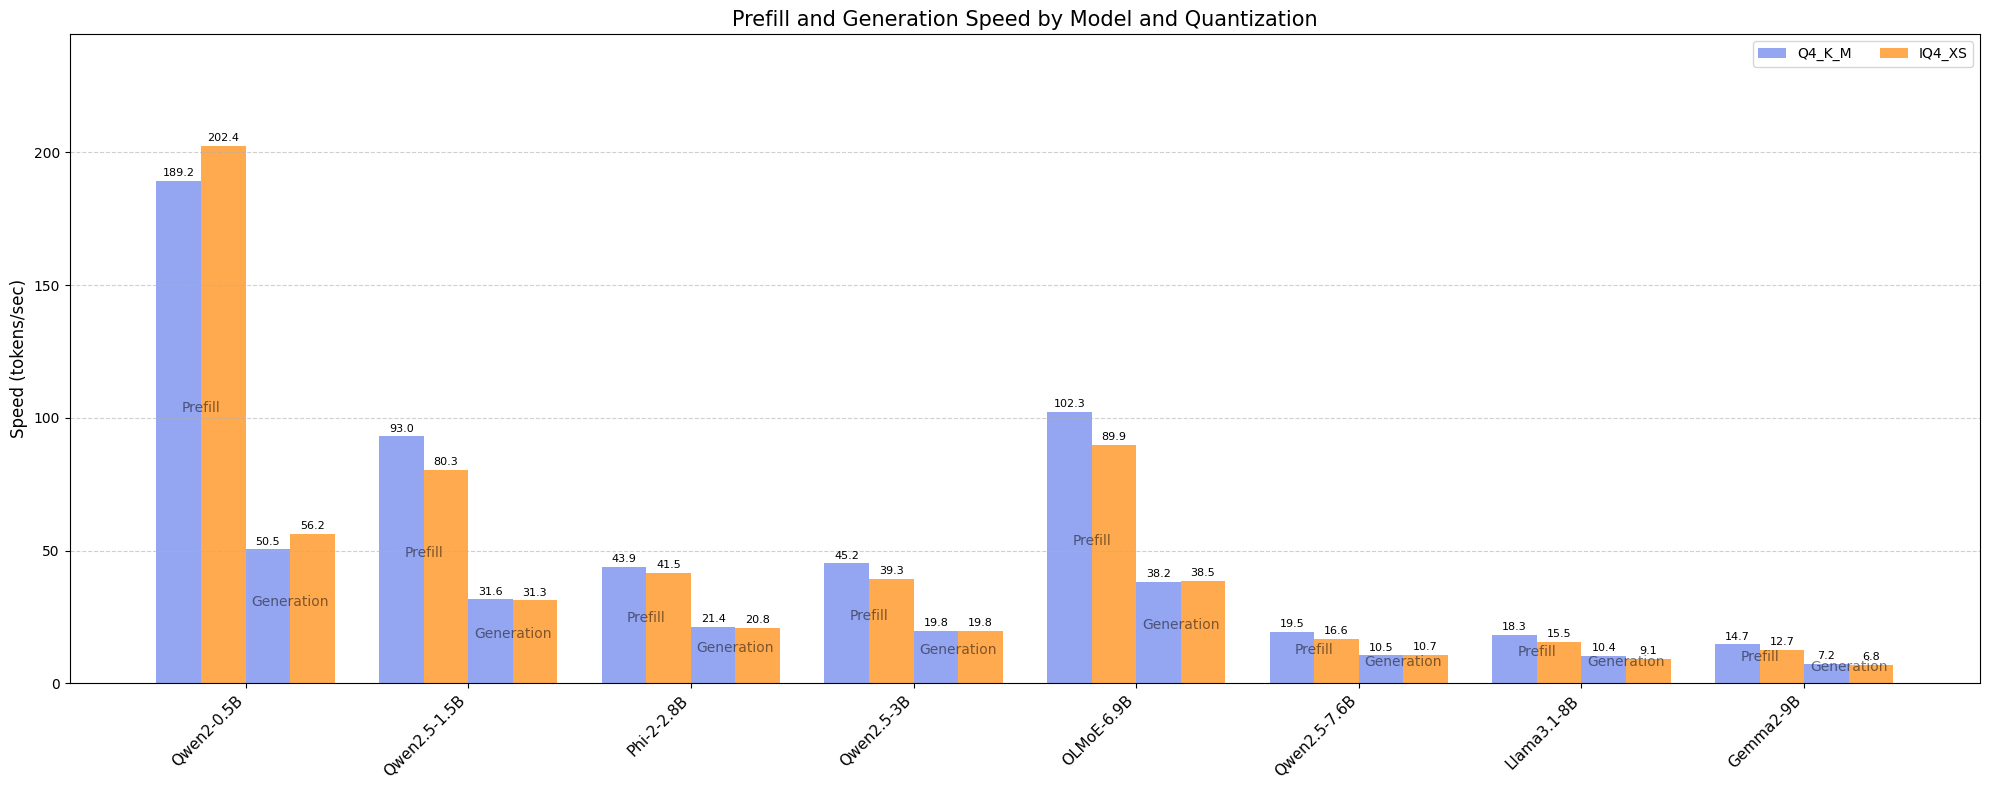

In [64]:

def label_bars(ax, bars):
    ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=8)

def label_group(ax, x_center, y_value, text):
    ax.text(
        x_center,
        y_value / 2,
        text,
        ha="center",
        va="bottom",
        fontsize=10,
        alpha=0.5
    )

# ---------------- Data ----------------
n = len(df8)
x = np.arange(n)
w = 0.2

# ---------------- Plot ----------------
fig, ax = plt.subplots(figsize=(20, 8))

# ---- Bars ----
b1 = ax.bar(
    x - 1.5*w,
    df8["prompt_prefill_speed"],
    w,
    label="Q4_K_M",
    color=prefill_color
)

b2 = ax.bar(
    x - 0.5*w,
    df16["prompt_prefill_speed"],
    w,
    label="IQ4_XS",
    color=generation_color
)

b3 = ax.bar(
    x + 0.5*w,
    df8["generation_decoder_speed"],
    w,
    color=prefill_color
)

b4 = ax.bar(
    x + 1.5*w,
    df16["generation_decoder_speed"],
    w,
    color=generation_color
)

# ---------------- Formatting ----------------
ax.set_xticks(x)
ax.set_xticklabels(df8["model_name"], rotation=45, ha="right", fontsize=11)
ax.set_ylabel("Speed (tokens/sec)", fontsize=12)
ax.set_title("Prefill and Generation Speed by Model and Quantization", fontsize=15)

ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend(fontsize=10, ncol=2)

# ---------------- Bar Value Labels ----------------
for bars in [b1, b2, b3, b4]:
    label_bars(ax, bars)

# ---------------- Group Labels ----------------
for i in range(n):
    # Prefill group
    prefill_x = x[i] - w
    prefill_y = max(
        df8["prompt_prefill_speed"].iloc[i],
        df16["prompt_prefill_speed"].iloc[i]
    )
    label_group(ax, prefill_x, prefill_y, "Prefill")

    # Generation group
    generation_x = x[i] + w
    generation_y = max(
        df8["generation_decoder_speed"].iloc[i],
        df16["generation_decoder_speed"].iloc[i]
    )
    label_group(ax, generation_x, generation_y, "Generation")

# ---------------- Final Touch ----------------
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
plt.tight_layout()
plt.show()


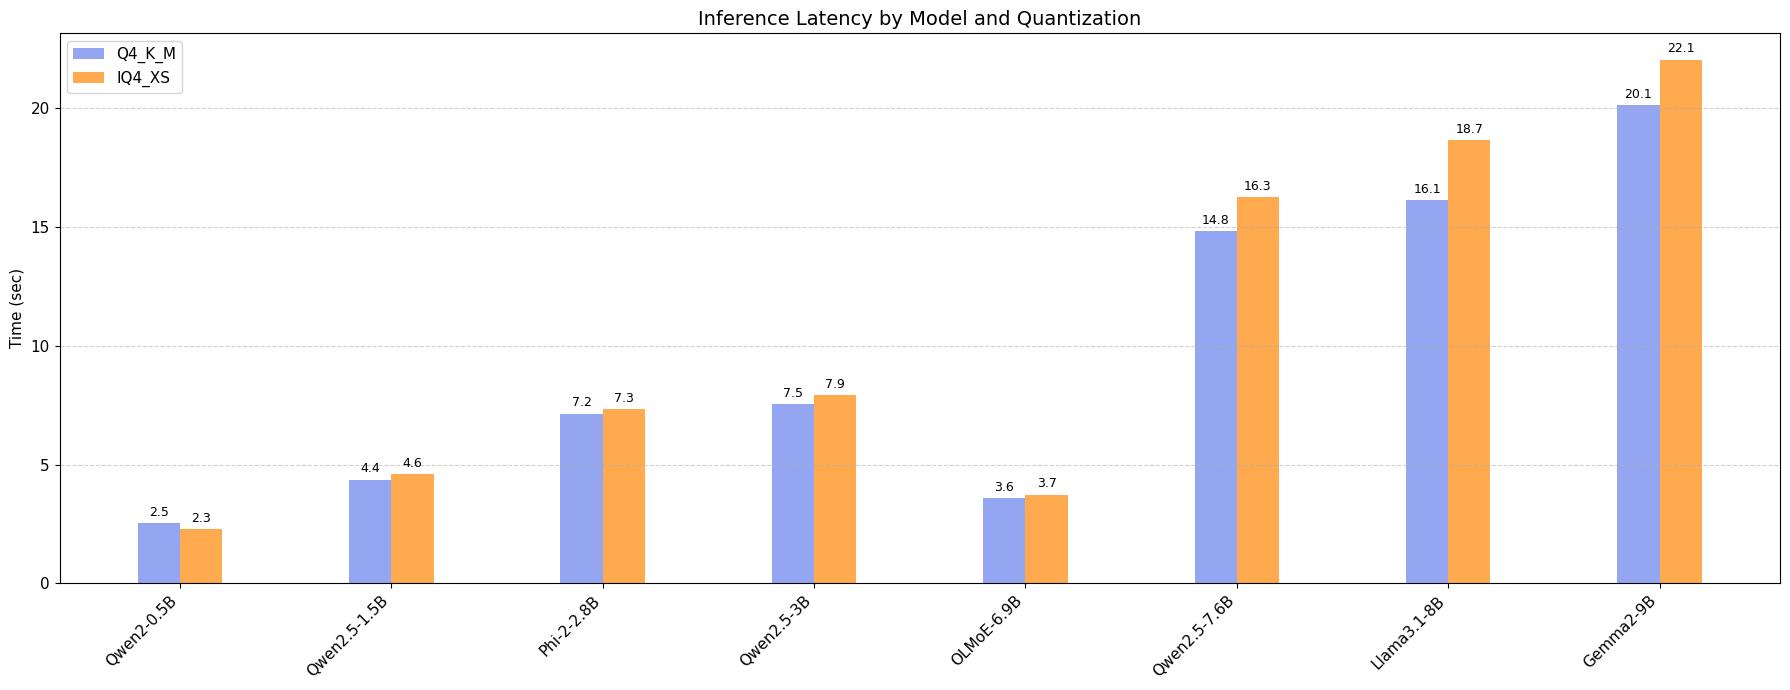

In [ ]:
def label_bars(ax, bars):
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)

fig, ax = plt.subplots(figsize=(18, 7))

# ---- Q4_K_M ----
b1 = ax.bar(
    x - w/2,
    df8["prefill_latency"],
    w,
    label="Q4_K_M",
    color=prefill_color
)

b2 = ax.bar(
    x - w/2,
    df8["generation_latency"],
    w,
    label="Q4_K_M",
    color=prefill_color
)

b3 = ax.bar(
    x - w/2,
    df8["inference_latency"],
    w,
    label="Q4_K_M",
    color=prefill_color
)


# ---- IQ4_XS ----
b4 = ax.bar(
    x + w/2,
    df16["prefill_latency"],
    w,
    label="IQ4_XS",
    color=generation_color
)

b5 = ax.bar(
    x + w/2,
    df16["generation_latency"],
    w,
    label="IQ4_XS",
    color=generation_color
)

b6 = ax.bar(
    x - w/2,
    df16["inference_latency"],
    w,
    label="IQ4_XS",
    color=prefill_color
)

# ---- Formatting ----
ax.set_xticks(x)
ax.set_xticklabels(df8["model_name"], rotation=45, ha="right", fontsize=11)
ax.set_ylabel("Time (sec)", fontsize=11)
ax.set_title("Inference Latency by Model and Quantization", fontsize=14)
ax.tick_params(axis="y", labelsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend(fontsize=11)

label_bars(ax, b1)
label_bars(ax, b2)

plt.tight_layout()
plt.show()


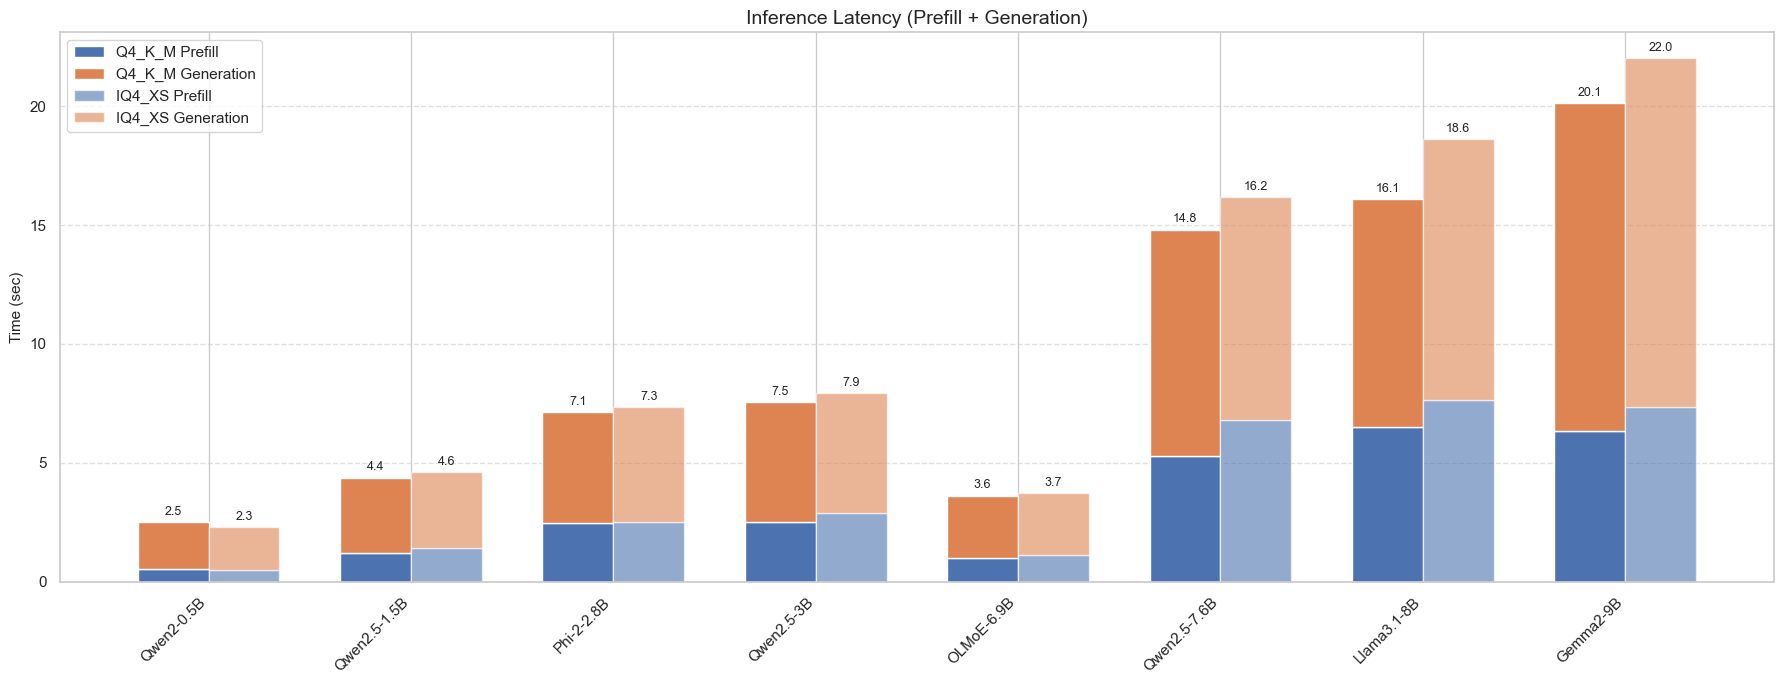

In [72]:
import matplotlib.pyplot as plt
import numpy as np

def label_bars(ax, bars):
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)

# ---- Setup ----
x = np.arange(len(df8["model_name"]))
w = 0.35

prefill_color = "#4C72B0"
generation_color = "#DD8452"

fig, ax = plt.subplots(figsize=(18, 7))

# =======================
# Q4_K_M (df8)
# =======================
b1 = ax.bar(
    x - w/2,
    df8["prefill_latency"],
    w,
    label="Q4_K_M Prefill",
    color=prefill_color
)

b2 = ax.bar(
    x - w/2,
    df8["generation_latency"],
    w,
    bottom=df8["prefill_latency"],
    label="Q4_K_M Generation",
    color=generation_color
)

# =======================
# IQ4_XS (df16)
# =======================
b3 = ax.bar(
    x + w/2,
    df16["prefill_latency"],
    w,
    label="IQ4_XS Prefill",
    color=prefill_color,
    alpha=0.6
)

b4 = ax.bar(
    x + w/2,
    df16["generation_latency"],
    w,
    bottom=df16["prefill_latency"],
    label="IQ4_XS Generation",
    color=generation_color,
    alpha=0.6
)

# ---- Formatting ----
ax.set_xticks(x)
ax.set_xticklabels(df8["model_name"], rotation=45, ha="right", fontsize=11)
ax.set_ylabel("Time (sec)", fontsize=11)
ax.set_title("Inference Latency (Prefill + Generation)", fontsize=14)
ax.tick_params(axis="y", labelsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.legend(fontsize=11)

# ---- Optional: label only the top (total inference latency) ----
label_bars(ax, b2)
label_bars(ax, b4)

plt.tight_layout()
plt.show()


In [68]:
df_model_name = df[['model_name']].copy()

df_model_name['model_name'] = (
    df_model_name['model_name']
    .astype(str)
    .str.replace('Q4_K_M', '', regex=False)
    .str.replace('IQ4_XS', '', regex=False)
    .str.replace('__', '_', regex=False)
    .str.replace('--', '-', regex=False)
    .str.strip('_- ')
)


In [69]:
df_model_name.head(10)

,model_name
0,Qwen2-0.5B
1,Qwen2.5-1.5B
2,Phi-2-2.8B
3,Qwen2.5-3B
4,OLMoE-6.9B
5,Qwen2.5-7.6B
6,Llama3.1-8B
7,Gemma2-9B
8,Qwen2-0.5B
9,Qwen2.5-1.5B


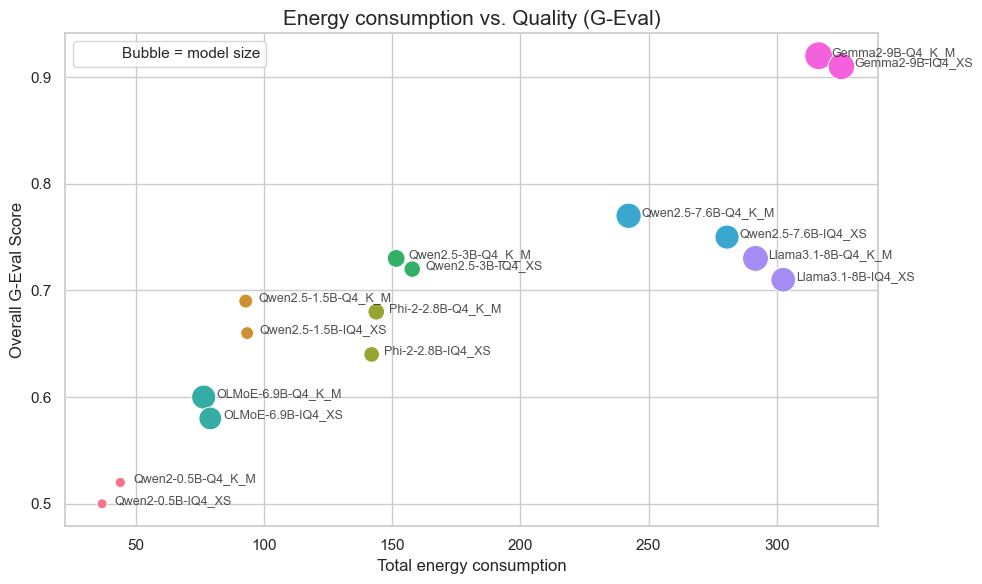

In [70]:

# Set the visual style
sns.set(style="whitegrid")

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='total_energy_consumption',
    y='Overall_G-Eval',
    size='model_weight',
    hue=df_model_name['model_name'],
    sizes=(50, 400),
    palette='husl',
    legend=False
)

# Set titles and labels
plt.title('Energy consumption vs. Quality (G-Eval)', fontsize=15)
plt.xlabel('Total energy consumption', fontsize=12)
plt.ylabel('Overall G-Eval Score', fontsize=12)

# Add labels for each model point
for i in range(len(df)):
    plt.text(
        df['total_energy_consumption'].iat[i] + 5,  # Small offset for readability
        df['Overall_G-Eval'].iat[i],
        str(df['model_name'].iat[i]),
        fontsize=9,
        alpha=0.8
    )

# Add text-only legend
legend_handle = Line2D(
    [], [],
    linestyle='none',
    marker=None,
    label='Bubble = model size'
)

plt.legend(
    handles=[legend_handle],
    frameon=True,
    loc='best'
)

plt.grid(True)
plt.tight_layout()
plt.show()


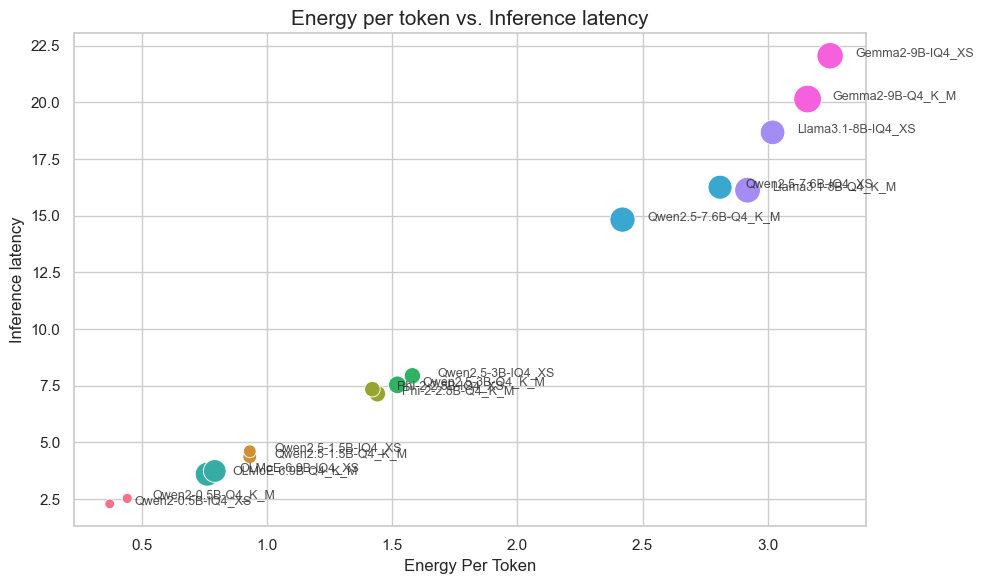

In [71]:

# Set the visual style
sns.set(style="whitegrid")

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='energy_per_token',
    y='inference_latency',
    size='model_weight',
    hue=df_model_name['model_name'],
    sizes=(50, 400),
    palette='husl',
    legend=False
)

# Set titles and labels
plt.title('Energy per token vs. Inference latency', fontsize=15)
plt.xlabel('Energy Per Token', fontsize=12)
plt.ylabel('Inference latency', fontsize=12)

# Add labels for each model point
for i in range(len(df)):
    plt.text(
        df['energy_per_token'].iat[i] + 0.1,  # Small offset for readability
        df['inference_latency'].iat[i],
        str(df['model_name'].iat[i]),
        fontsize=9,
        alpha=0.8
    )



plt.grid(True)
plt.tight_layout()
plt.show()
